# LLM-Powered Customer Feedback Analytics Dashboard
**Author:** Hyunjae Chung  
**Dataset:** Amazon Video Game Reviews (~497,000 reviews)  
**Goal:** Use GPT-4o-mini to classify sentiment of video game reviews 
and analyze customer satisfaction trends from 2010 to 2018.

LLM Project by Hyunjae Chung

## Step 1: Data Loading and Exploration
Load the raw dataset and inspect its structure, total rows, column names, and sample records.

In [ ]:
import pandas as pd

# Load the Video Games review dataset (JSON Lines format)
df = pd.read_json('./Video_Games_5.json', lines = True)

# Check total rows and column names
print(df.shape)
print(df.columns.tolist())

(497577, 12)
['overall', 'verified', 'reviewTime', 'reviewerID', 'asin', 'reviewerName', 'reviewText', 'summary', 'unixReviewTime', 'vote', 'style', 'image']


In [2]:
# Preview the first 3 rows to inspect data structure
df.head(3)

,overall,verified,reviewTime,reviewerID,asin,reviewerName,reviewText,summary,unixReviewTime,vote,style,image
0,5,True,"10 17, 2015",A1HP7NVNPFMA4N,0700026657,Ambrosia075,"This game is a bit hard to get the hang of, bu...",but when you do it's great.,1445040000,NaN,NaN,NaN
1,4,False,"07 27, 2015",A1JGAP0185YJI6,0700026657,travis,I played it a while but it was alright. The st...,"But in spite of that it was fun, I liked it",1437955200,NaN,NaN,NaN
2,3,True,"02 23, 2015",A1YJWEXHQBWK2B,0700026657,Vincent G. Mezera,ok game.,Three Stars,1424649600,NaN,NaN,NaN


## Step 2: Data Cleaning
Remove rows with missing review text and short reviews (fewer than 5 words) to ensure data quality before analysis.

In [3]:
# Keep only relevant columns for analysis
df = df[['overall', 'reviewText', 'reviewTime', 'summary']]

# Confirm new shape (rows should stay the same, columns reduced to 4)
print(df.shape)
df.head(3)

(497577, 4)


,overall,reviewText,reviewTime,summary
0,5,"This game is a bit hard to get the hang of, bu...","10 17, 2015",but when you do it's great.
1,4,I played it a while but it was alright. The st...,"07 27, 2015","But in spite of that it was fun, I liked it"
2,3,ok game.,"02 23, 2015",Three Stars


In [4]:
# Data cleaning

# Step 1: Remove rows where reviewText is missing (NaN)
df = df.dropna(subset=['reviewText'])

# Step 2: Remove short reviews with fewer than 5 words (e.g., "ok game", "great")
df = df[df['reviewText'].str.split().str.len() >= 5]

# Step 3: Confirm how many reviews remain after cleaning
print(df.shape)

(418515, 4)


## Step 3: Filter by Year
Convert reviewTime to datetime, extract year, and focus on 2010 onwards for sufficient data volume.

In [5]:
# Convert reviewTime to datetime format for trend analysis
df['reviewTime'] = pd.to_datetime(df['reviewTime'])

# Extract year from reviewTime
df['year'] = df['reviewTime'].dt.year

# Check the year distribution
df['year'].value_counts().sort_index()

1999       81
2000     1859
2001     5128
2002     7352
2003     6999
2004     7247
2005     7785
2006     7045
2007    10470
2008    19119
2009    19902
2010    18331
2011    19242
2012    26497
2013    47853
2014    58280
2015    63561
2016    55865
2017    27603
2018     8296
Name: year, dtype: int64

In [6]:
# Keep reviews from 2010 onwards (sufficient data volume for trend analysis)
df = df[df['year'] >= 2010]

# Reset index after filtering
df = df.reset_index(drop = True)

# Final check
print(df.shape)
df.head(3)

(325528, 5)


,overall,reviewText,reviewTime,summary,year
0,5,"This game is a bit hard to get the hang of, bu...",2015-10-17,but when you do it's great.,2015
1,4,I played it a while but it was alright. The st...,2015-07-27,"But in spite of that it was fun, I liked it",2015
2,2,"found the game a bit too complicated, not what...",2015-02-20,Two Stars,2015


In [ ]:
# Save cleaned data to CSV for later use
df.to_csv('./cleaned_reviews.csv', index = False)
print("Saved successfully")

# part 1 over

Saved successfully


### Data Cleaning Summary
- Started with **497,577** raw reviews
- After cleaning: **418,515** reviews
- After filtering (2010+): **325,528** reviews ready for analysis

In [ ]:
df = pd.read_csv('./cleaned_reviews.csv')
print(df.shape)
df.head(3)

(325528, 5)


,overall,reviewText,reviewTime,summary,year
0,5,"This game is a bit hard to get the hang of, bu...",2015-10-17,but when you do it's great.,2015
1,4,I played it a while but it was alright. The st...,2015-07-27,"But in spite of that it was fun, I liked it",2015
2,2,"found the game a bit too complicated, not what...",2015-02-20,Two Stars,2015


## Step 4: Connect to OpenAI API
Set up the OpenAI client using the API key to enable GPT-4o-mini requests.

In [9]:
# Install OpenAI library (run once)
import subprocess
subprocess.run(['pip', 'install', 'openai'], capture_output=True)

import os
from dotenv import load_dotenv
from openai import OpenAI

# Load API key from .env file (keeps the key out of the code)
load_dotenv()
client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

# Test - make sure it works
response = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Reply with exactly: API connection successful"}]
)
print(response.choices[0].message.content)

API connection successful


## Step 5: Test Pipeline on 100 Samples
Before scaling up, validate the sentiment analysis pipeline on a small sample of 100 reviews.

In [10]:
import time

# Extract 100 samples for testing
sample_df = df.sample(n=100, random_state = 42).reset_index(drop = True)
print(f"샘플 크기: {len(sample_df)}")

# Define sentiment analysis function
def analyze_sentiment(review_text):
    try:
        response = client.chat.completions.create(
            model="gpt-4o-mini",
            messages=[
                {
                    "role": "system",
                    "content": "You are a sentiment analysis assistant. Analyze the sentiment of the given video game review and respond with ONLY one word: Positive, Negative, or Neutral."
                },
                {
                    "role": "user", 
                    "content": f"Review: {review_text}"
                }
            ],
            max_tokens=10
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return "Error"

# Test with a single review first
test_review = sample_df['reviewText'][0]
print(f"Review: {test_review[:100]}...")
print(f"Sentiment: {analyze_sentiment(test_review)}")

샘플 크기: 100
Review: excellent product, product as stated - excellent service! A+...
Sentiment: Positive


In [11]:
# Run sentiment analysis on all 100 samples
sentiments = []

for i, row in sample_df.iterrows():
    sentiment = analyze_sentiment(row['reviewText'])
    sentiments.append(sentiment)

    # Print progress every 10 reviews
    if (len(sentiments)) % 10 == 0:
        print(f"Progress: {len(sentiments)}/100 completed")

    time.sleep(0.5)  # Pause to avoid hitting API rate limit

# Add sentiment results to dataframe
sample_df['sentiment'] = sentiments

print("\nDone!")
print(sample_df['sentiment'].value_counts())

Progress: 10/100 completed
Progress: 20/100 completed
Progress: 30/100 completed
Progress: 40/100 completed
Progress: 50/100 completed
Progress: 60/100 completed
Progress: 70/100 completed
Progress: 80/100 completed
Progress: 90/100 completed
Progress: 100/100 completed

Done!
Positive    57
Negative    24
Neutral     19
Name: sentiment, dtype: int64


## Step 6: Scale Up to 1,000 Samples (Stratified by Year)
Sample 111 reviews per year (2010 to 2018) to ensure equal representation across all years. This prevents bias in trend analysis.

In [12]:
# Scale up to 1,000 samples
# Sample 1,000 reviews evenly across years (2010-2018)
sample_1000 = df.groupby('year', group_keys=False).apply(
    lambda x: x.sample(min(len(x), 111), random_state=42)
).reset_index(drop=True).head(1000)

print(f"Total samples: {len(sample_1000)}")
print("Samples per year:")
print(sample_1000['year'].value_counts().sort_index())

Total samples: 999
Samples per year:
2010    111
2011    111
2012    111
2013    111
2014    111
2015    111
2016    111
2017    111
2018    111
Name: year, dtype: int64


## Step 7: Run Sentiment Analysis on 1,000 Samples
Run GPT-4o-mini on all 999 sampled reviews. Results are saved to CSV for later use.

In [ ]:
# Run sentiment analysis on 1,000 samples
# NOTE: This was run once to generate sentiment_results.csv.
# It is commented out to avoid re-running GPT (saves time and API cost).
# To regenerate, uncomment the block below.

# sentiments_1000 = []
# for i, row in sample_1000.iterrows():
#     sentiment = analyze_sentiment(row['reviewText'])
#     sentiments_1000.append(sentiment)
#     if len(sentiments_1000) % 100 == 0:
#         print(f"Progress: {len(sentiments_1000)}/999 completed")
#     time.sleep(0.5)
# sample_1000['sentiment'] = sentiments_1000
# sample_1000.to_csv('./sentiment_results.csv', index=False)

# Load the saved results instead of re-running GPT
sample_1000 = pd.read_csv('./sentiment_results.csv')
print("Loaded saved results from CSV")
print(sample_1000['sentiment'].value_counts())

Loaded saved results from CSV
Positive    668
Negative    209
Neutral     116
Mixed         6
Name: sentiment, dtype: int64


### Result: 1,000-Sample Sentiment Distribution
- **Positive: 668 (66.9%)**
- **Negative: 209 (20.9%)**
- **Neutral: 116 (11.6%)**
- Mixed: 6 (0.6%)

Positive dominates, consistent with Amazon's general review bias toward positive feedback.

**Note:** 6 out of 999 responses (0.6%) returned "Mixed" instead of the 
requested Positive/Negative/Neutral classification, highlighting that 
LLMs do not always follow instructions precisely. These cases were 
excluded from trend analysis.

## Step 8: Sentiment Trend Analysis by Year
Group sentiment results by year and calculate percentage distribution to identify how customer satisfaction changed over time.

In [14]:
import matplotlib.pyplot as plt

# Analyze sentiment trend by year
# Group by year and calculate sentiment percentage per year
yearly_sentiment = sample_1000.groupby(['year', 'sentiment']).size().unstack(fill_value=0)

# Convert counts to percentages
yearly_sentiment_pct = yearly_sentiment.div(yearly_sentiment.sum(axis=1), axis=0) * 100

print(yearly_sentiment_pct.round(1))

sentiment  Mixed  Negative  Neutral  Positive
year                                         
2010         0.0      18.9     13.5      67.6
2011         0.0      22.5     17.1      60.4
2012         0.9      18.0      9.9      71.2
2013         0.0      16.2     10.8      73.0
2014         2.7      20.7      4.5      72.1
2015         0.9      22.5      7.2      69.4
2016         0.0      23.4     11.7      64.9
2017         0.0      22.5     17.1      60.4
2018         0.9      23.4     12.6      63.1


### Key Insight: Sentiment Trend (2010–2018)
The data shows that **Positive sentiment peaked in 2013 at 73%** and declined 
to around 60% by 2017–2018, suggesting a gradual decrease in customer 
satisfaction in the video game market over this period.

Negative sentiment remained relatively stable at **17–23% throughout**, 
while Neutral reviews increased slightly toward 2017–2018.

## Step 9: Visualization
Plot sentiment percentages per year as a line chart to clearly show the direction of change over time (2010 to 2018).

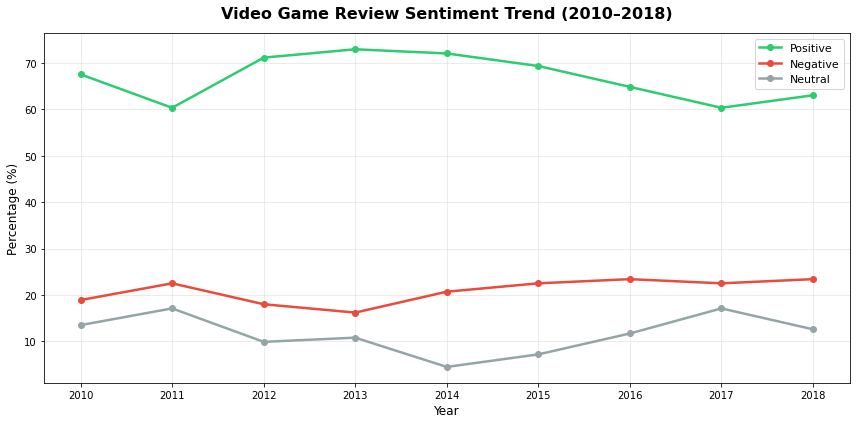

Chart saved!


In [ ]:
# Visualize sentiment trend by year
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each sentiment as a line
colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6', 'Mixed': '#f39c12'}

for sentiment in ['Positive', 'Negative', 'Neutral']:
    if sentiment in yearly_sentiment_pct.columns:
        ax.plot(
            yearly_sentiment_pct.index,
            yearly_sentiment_pct[sentiment],
            marker='o',
            linewidth=2.5,
            label=sentiment,
            color=colors[sentiment]
        )

ax.set_title('Video Game Review Sentiment Trend (2010–2018)', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xticks(yearly_sentiment_pct.index)
plt.tight_layout()
plt.savefig('./sentiment_trend.png', dpi=150)
plt.show()

print("Chart saved!")

Plotted sentiment percentages per year as a line chart to visualize how customer satisfaction shifted from 2010 to 2018. Each sentiment is color-coded — green for Positive, red for Negative, gray for Neutral.

Line charts are best for showing trends over time. Bar charts would show absolute values but make it harder to see the direction of change.

## Step 10: Validation — Star Rating vs GPT Sentiment
Cross-check GPT's sentiment classification against the existing star ratings (`overall`) to validate the model and find cases where they disagree. This reveals whether star ratings alone fully capture customer sentiment.

In [16]:
# Step 10-1 Compare star rating (overall) vs GPT sentiment

# Map star ratings to expected sentiment for comparison
# 4-5 stars = Positive, 3 = Neutral, 1-2 = Negative
def rating_to_sentiment(stars):
    if stars >= 4:
        return 'Positive'
    elif stars == 3:
        return 'Neutral'
    else:
        return 'Negative'

sample_1000['rating_sentiment'] = sample_1000['overall'].apply(rating_to_sentiment)

# Compare: does GPT sentiment match the star-based sentiment?
sample_1000['match'] = sample_1000['sentiment'] == sample_1000['rating_sentiment']

# Overall agreement rate
agreement_rate = sample_1000['match'].mean() * 100
print(f"Agreement rate between star ratings and GPT sentiment: {agreement_rate:.1f}%")
print(f"\nMatching cases: {sample_1000['match'].sum()}")
print(f"Disagreeing cases: {(~sample_1000['match']).sum()}")

Agreement rate between star ratings and GPT sentiment: 83.2%

Matching cases: 831
Disagreeing cases: 168


In [17]:
# Step 10-2: Analyze disagreement cases

# Filter disagreeing cases
disagreements = sample_1000[sample_1000['match'] == False].copy()

# Break down by type of disagreement
print("Disagreement breakdown:")
print(disagreements.groupby(['rating_sentiment', 'sentiment']).size())

print(f"\nTotal disagreements: {len(disagreements)}")

Disagreement breakdown:
rating_sentiment  sentiment
Negative          Neutral       4
Neutral           Mixed         2
                  Negative     57
                  Positive      7
Positive          Mixed         4
                  Negative     22
                  Neutral      72
dtype: int64

Total disagreements: 168


In [18]:
# Step 10-3: Look at specific disagreement examples

# Most interesting case: High stars but GPT says Negative
high_stars_negative = sample_1000[
    (sample_1000['rating_sentiment'] == 'Positive') &
    (sample_1000['sentiment'] == 'Negative')
][['overall', 'reviewText', 'rating_sentiment', 'sentiment']].head(5)

print("=== High Star Rating but GPT says Negative ===")
for i, row in high_stars_negative.iterrows():
    print(f"\nStars: {row['overall']}")
    print(f"Review: {row['reviewText'][:200]}")
    print(f"GPT Sentiment: {row['sentiment']}")
    print("-" * 50)

=== High Star Rating but GPT says Negative ===

Stars: 5
Review: It was a great game because it was so addicting and challenging --- yet simplistic and in the realm of its own in terms of the game world.

However, please. I was looking at the prices listed for this
GPT Sentiment: Negative
--------------------------------------------------

Stars: 5
Review: My review is in 2 parts, one for content (story, etc.), which contains spoilers, the other for gameplay, which does not contain spoilers (barely anyway).  At this point, I have completed the game twic
GPT Sentiment: Negative
--------------------------------------------------

Stars: 4
Review: Red Faction Guerrilla has a great story and great game play but can be extremely frustrating during the setup process. I am an advanced computer user and had it not been for this fact, I would not hav
GPT Sentiment: Negative
--------------------------------------------------

Stars: 5
Review: My 7 year old daughter loves the nintendogs series an

### Key Insight: Why Star Ratings and GPT Sentiment Disagree

The most common disagreement pattern: **reviews with high star ratings (4-5) but Negative GPT sentiment**.

Looking at specific examples, these reviews share a common structure:
- "The game is great, BUT the **price** is too high"
- "Great gameplay, BUT **extremely frustrating** setup"
- "Love the game, BUT concerned about **availability**"

This reveals that **star ratings reflect overall satisfaction with the game**, while **GPT reads the full review text including complaints about price, availability, and frustration**. 

This is exactly why sentiment analysis adds value beyond star ratings alone: it captures nuanced feedback that a single number cannot.

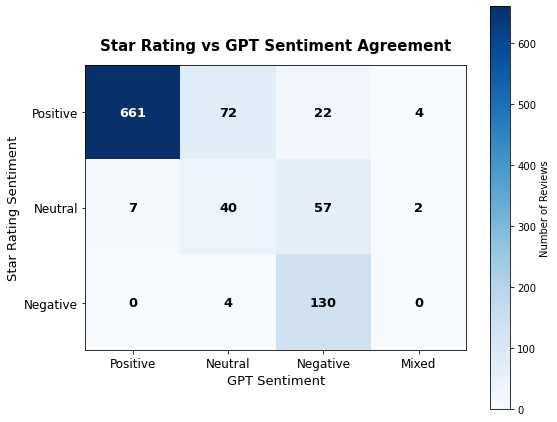

Heatmap saved!


In [ ]:
# Step 10-4: Visualize disagreement breakdown as a heatmap

import numpy as np

# Create a pivot table for disagreement visualization
pivot = sample_1000.groupby(
    ['rating_sentiment', 'sentiment']
).size().unstack(fill_value=0)

# Reorder rows and columns
row_order = ['Positive', 'Neutral', 'Negative']
col_order = ['Positive', 'Neutral', 'Negative', 'Mixed']

pivot = pivot.reindex(index=row_order, columns=col_order, fill_value=0)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='Blues')

ax.set_xticks(range(len(col_order)))
ax.set_yticks(range(len(row_order)))
ax.set_xticklabels(col_order, fontsize=12)
ax.set_yticklabels(row_order, fontsize=12)
ax.set_xlabel('GPT Sentiment', fontsize=13)
ax.set_ylabel('Star Rating Sentiment', fontsize=13)
ax.set_title('Star Rating vs GPT Sentiment Agreement', fontsize=15, fontweight='bold', pad=15)

# Add numbers inside each cell
for i in range(len(row_order)):
    for j in range(len(col_order)):
        ax.text(j, i, str(pivot.values[i][j]),
                ha='center', va='center',
                fontsize=13, fontweight='bold',
                color='white' if pivot.values[i][j] > 200 else 'black')

plt.colorbar(im, ax=ax, label='Number of Reviews')
plt.tight_layout()
plt.savefig('./agreement_heatmap.png', dpi=150)
plt.show()
print("Heatmap saved!")

### Key Insight: Agreement Heatmap

The diagonal (661, 40, 130) represents cases where star ratings and GPT sentiment agree.

Notable disagreement patterns:
- **Positive stars, Neutral GPT (72 cases):** High-rated reviews often contain hedged language such as "good but..." that GPT interprets as less than fully positive
- **Neutral stars, Negative GPT (57 cases):** 3-star reviews tend to contain more negative language than the rating suggests, indicating that a 3-star rating often reflects dissatisfaction rather than true neutrality
- **Negative stars align strongly with GPT Negative (130 cases):** Negative emotions are expressed clearly in text, making them easier for GPT to detect

Overall, GPT sentiment captures nuance that star ratings alone cannot, particularly for mid-range (3-star) reviews.

In [ ]:
# Check saved files
import os

project_path = '.'
files = os.listdir(project_path)
for f in files:
    print(f)

agreement_heatmap.png
Video_Games_5.json
sentiment_trend.png
sentiment_results.csv
LLM Project.ipynb
dashboard.py
.gitignore
.env
.ipynb_checkpoints
cleaned_reviews.csv
Video_Games_5.json.zip


In [21]:
import subprocess
result = subprocess.run(['pip', 'install', 'langchain', 'langchain-openai', 'python-dotenv'], capture_output=True, text=True)
print("Installed!")

Installed!


In [22]:
import subprocess
subprocess.run(['pip', 'install', '--upgrade', 'pydantic'], capture_output=True, text=True)
print("Done!")

Done!


In [23]:
import langchain
import langchain_openai
print("LangChain version:", langchain.__version__)
print("Ready!")

LangChain version: 0.3.30
Ready!


## Step 11: Refactoring with LangChain
Re-implement the sentiment analysis using LangChain instead of calling the OpenAI API directly. LangChain provides a structured way to manage prompts and models through reusable components (prompt templates, chat models, and output parsers), which makes the pipeline easier to maintain and extend.

In [24]:
from langchain_openai import ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

# 1. Define the chat model (reads API key from environment)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

# 2. Define a reusable prompt template
prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a sentiment analysis assistant. Analyze the sentiment of the given video game review and respond with ONLY one word: Positive, Negative, or Neutral."),
    ("user", "Review: {review}")
])

# 3. Define an output parser to extract clean text
parser = StrOutputParser()

# 4. Chain the components together: prompt -> model -> parser
sentiment_chain = prompt | llm | parser

# Test with a single review
test_review = "This game is amazing! Best purchase I've made all year."
result = sentiment_chain.invoke({"review": test_review})
print("Test review sentiment:", result)

Test review sentiment: Positive


### LangChain Implementation Note
This LangChain chain produces the same sentiment classifications as the earlier direct OpenAI implementation, but organizes the logic into reusable components. While a single classification task does not strictly require LangChain, this structure makes the pipeline easier to extend into multi-step workflows (for example, adding topic extraction or summarization as additional chain steps).

## Step 12: BigQuery Integration (End-to-End Pipeline)

Connect to BigQuery from Python to complete the end-to-end pipeline. The sentiment results were uploaded to BigQuery, and here we query them back using SQL, returning the results directly as a pandas DataFrame. This demonstrates the full flow: local analysis -> cloud data warehouse -> SQL query -> back into Python for further use.

In [1]:
from google.cloud import bigquery
from google.oauth2 import service_account

# 1. Load credentials from the service account key file
credentials = service_account.Credentials.from_service_account_file(
    "bigquery-key.json"
)

# 2. Create a client bound to the project
client = bigquery.Client(
    credentials=credentials,
    project="game-review-analytics"
)

# 3. Query the sentiment results table (project.dataset.table)
query = """
    SELECT sentiment, COUNT(*) AS count
    FROM `game-review-analytics.game_reviews.sentiment_results`
    GROUP BY sentiment
    ORDER BY count DESC
"""

# 4. Run the query and load results directly into a pandas DataFrame
df_bq = client.query(query).to_dataframe()
print(df_bq)

/Users/jaechung/Desktop/game_review_project/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.2) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/jaechung/Desktop/game_review_project/.venv/lib/python3.10/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


  sentiment  count
0  Positive    668
1  Negative    209
2   Neutral    116
3     Mixed      6
